Datasets:  

| Accession | Biological Source | Number of Cells | Gene Coverage | Cell Types | Protocol | Processed Matrix Size |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **GSE65525** (Klein) | Mouse Embryonic Stem Cells | 2,717 | 24,175 | 4 | inDrop | 45.0 MB |
| **GSE60361** (Zeisel) | Mouse Cerebral Cortex | 3,005 | 19,972 | 7 to 9 | STRT-seq (Fluidigm C1) | 10.7 MB |
| **GSE57249** (Biase) | Mouse Embryos | 56 | 25,734 | 4 | SMARTer (Smart-Seq) | 2.8 MB |
| **GSE59739** (Usokin) | Mouse Dorsal Root Ganglion (DRG) | 799 | 25,334 | 4 | NA| NA |

In [ ]:
import copy
import gzip
import tarfile
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sc3s
import scanpy as sc
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score


(Dropped this dataset - annotation data was not able to be retrieved succesfully)

GSE60361 mouse cerebral cortex dataset. 

The GEO entry for this one is not entirely complete. The samples are not labeled with their corresponding metadata and annotaions within the GEO data. Metadata, such as cell-type annotations are stored seprately. Each individual cell has has a Sample Accession (GSM) recor that needs to be downlaodded seprately. The authors recommend just retrieving the data from their own site, but their link is dead. tHat's why the data is being loaded from GEO here and re-assembled.

a row for each gene
a columns are each cell 
value is an integer count of the number of molecule counts. i.e. gene  expression level

Pollen: GSE59739 / SRP041736 (Human tissue/cell lines and neural cells across low and high coverage)




In [2]:
# Helper to download files cleanly
def fetch_file(url: str, dest: Path):
    if not dest.exists() or dest.stat().st_size == 0:
        print(f"Downloading {dest.name}...")
        try:
            urllib.request.urlretrieve(url, dest)
        except Exception as e:
            if dest.exists(): dest.unlink()
            raise e

def get_GSE59739():
    # -----------------------------------------------------------------------------
    # 1. Download Data & Series Matrices
    # -----------------------------------------------------------------------------
    expr_file = Path("GSE59739_DataTable.txt.gz")
    base_url = "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE59nnn/GSE59739"

    fetch_file(f"{base_url}/suppl/{expr_file}", expr_file)

    # -----------------------------------------------------------------------------
    # 2. Dynamic Metadata Parsing across GPL Platforms
    # -----------------------------------------------------------------------------
    meta_dfs = []
    for gpl in ["GPL11002", "GPL13112"]:
        matrix_file = Path(f"GSE59739-{gpl}_series_matrix.txt.gz")
        fetch_file(f"{base_url}/matrix/{matrix_file}", matrix_file)
        
        sample_ids, cell_names, characteristics = [], [], {}
        with gzip.open(matrix_file, 'rt', encoding='utf-8', errors='ignore') as f:
            for line in f:
                if line.startswith("!Sample_geo_accession"):
                    sample_ids = [x.strip('"\n\r') for x in line.split('\t')[1:]]
                elif line.startswith("!Sample_title"):
                    cell_names = [x.strip('"\n\r') for x in line.split('\t')[1:]]
                elif line.startswith("!Sample_characteristics_ch1"):
                    vals = [x.strip('"\n\r') for x in line.split('\t')[1:]]
                    if vals and ":" in vals[0]:
                        key = vals[0].split(":")[0].strip()
                        characteristics[key] = [v.split(":", 1)[-1].strip() if ":" in v else v for v in vals]
                elif line.startswith("!series_matrix_table_begin"):
                    break

        df = pd.DataFrame(characteristics, index=sample_ids)
        if cell_names and len(cell_names) == len(df):
            df = df.set_index(pd.Index(cell_names, name='cell_name'))
        meta_dfs.append(df)

    geo_metadata = pd.concat(meta_dfs)

    # -----------------------------------------------------------------------------
    # 3. Load Expression Matrix & Build AnnData
    # -----------------------------------------------------------------------------
    print("Loading expression matrix...")
    raw_expr = pd.read_csv(expr_file, sep="\t", index_col=0).T
    raw_expr.columns.name, raw_expr.index.name = None, None

    # Vectorized separation of embedded non-numeric metadata rows (e.g., plate IDs)
    numeric_cols = raw_expr.apply(lambda col: pd.to_numeric(col, errors='coerce')).notna().all()
    clean_expr = raw_expr.loc[:, numeric_cols].astype(float)
    embedded_meta = raw_expr.loc[:, ~numeric_cols]

    # Build AnnData Object
    obs_df = geo_metadata.reindex(clean_expr.index).join(embedded_meta)
    GSE59739_adata = sc.AnnData(X=clean_expr.values, obs=obs_df, var=pd.DataFrame(index=clean_expr.columns))

    GSE59739_adata.obs_names_make_unique()
    GSE59739_adata.var_names_make_unique()
    return GSE59739_adata

#Commented out for the moment, the otherdataset is being prioritized
#GSE59739_adata = get_GSE59739()
#print(f"\nSuccess! Summary of Usoskin Dataset (GSE59739):\n{GSE59739_adata}")

GSE365525 Klein Dataset - 

These cells here are all emryonic stem cells, so they don't actually have different types to cluster on. They are however in different stages of differentiation. day number will indicate how far along a cell is in differentiation.

I can use this set to observer more subtle categories, rather than the hard label of cell type. Sub-groups might be days, LIF, and a few human K562 cells for control.

In [3]:
def get_GSE65525():

    # -----------------------------------------------------------------------------
    # 1. Download & Extract Supplementary Data
    # -----------------------------------------------------------------------------
    tar_file = Path("GSE65525_RAW.tar")
    extract_dir = Path("./GSE65525_extracted")

    if not tar_file.exists() or tar_file.stat().st_size == 0:
        print(f"Downloading {tar_file}...")
        urllib.request.urlretrieve("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSE65525&format=file", tar_file)

    if not extract_dir.exists():
        extract_dir.mkdir(parents=True, exist_ok=True)
        with tarfile.open(tar_file, "r") as tar:
            tar.extractall(path=extract_dir)

    # -----------------------------------------------------------------------------
    # 2. Parse Files & Build AnnData
    # -----------------------------------------------------------------------------
    print("Parsing dataset files...")
    dfs, obs_data = [], {}

    # Filter and sort mouse ES sample files
    mouse_files = sorted([f for f in extract_dir.glob("*GSM159949*") if f.name.endswith(('.csv', '.csv.gz', '.csv.bz2'))])

    for i, filepath in enumerate(mouse_files):
        # Read matrix (genes x cells) and transpose (cells x genes)
        df_t = pd.read_csv(filepath, index_col=0).T
        
        # Guarantee unique cell IDs (e.g., b0_cell1)
        df_t.index = [f"b{i}_{cid}" for cid in df_t.index]
        
        # Store metadata and count matrix separately (avoids adding/dropping columns later)
        stage = filepath.name.split("_")[2] if len(filepath.name.split("_")) > 2 else "unknown"
        for cid in df_t.index:
            obs_data[cid] = stage
            
        dfs.append(df_t)

    # Combine matrices
    expr_df = pd.concat(dfs)
    expr_df.columns.name, expr_df.index.name = None, None

    # Construct AnnData Object
    GSE65525_adata = sc.AnnData(
        X=expr_df.values.astype(float),
        obs=pd.DataFrame({"cell_stage": obs_data}),
        var=pd.DataFrame(index=expr_df.columns)
    )
    GSE65525_adata.var_names_make_unique()
    return GSE65525_adata

GSE65525_adata = get_GSE65525()
print(f"\nSuccess! Summary of Klein Dataset (GSE65525):\n{GSE65525_adata}")
print(f"\nCell Stage Distribution:\n{GSE65525_adata.obs['cell_stage'].value_counts()}")

Parsing dataset files...

Success! Summary of Klein Dataset (GSE65525):
AnnData object with n_obs × n_vars = 8669 × 24174
    obs: 'cell_stage'

Cell Stage Distribution:
cell_stage
d0    6885
d7     798
d4     683
d2     303
Name: count, dtype: int64


In [4]:
## printing data for a single cell, to validate
def _data_check():
    # Select the cell (using the cell at index 0)
    cell_idx = 0
    cell_id = GSE65525_adata.obs_names[cell_idx]
    cell_type = GSE65525_adata.obs['cell_stage'].iloc[cell_idx]

    print(f"Cell ID: {cell_id}")
    print(f"Cell Type (Stage): {cell_type}\n")

    # Extract expression data for that cell
    # (Handle potential sparse matrices using .toarray() just in case)
    if hasattr(GSE65525_adata.X, "toarray"):
        cell_expr_values = GSE65525_adata.X[cell_idx].toarray().flatten()
    else:
        cell_expr_values = GSE65525_adata.X[cell_idx]

    # map gene names to counts
    cell_expr = pd.Series(cell_expr_values, index=GSE65525_adata.var_names)

    # Filter out zeros, sort by highest expression, and format as a table
    expressed_genes = cell_expr[cell_expr > 0].sort_values(ascending=False)

    print(f"Proportion of genes expressed (>0 counts to total): {len(expressed_genes)} / {len(cell_expr)}")
    print("\15 Most Expressed Genes:")
    print(expressed_genes.head(15).to_frame(name="Count"))
_data_check()
del _data_check

Cell ID: b0_0
Cell Type (Stage): d0

Proportion of genes expressed (>0 counts to total): 14195 / 24174
 Most Expressed Genes:
        Count
Rn4.5s  359.0
Rn45s   148.0
Rpl41   124.0
Eef1a1  107.0
Rplp1    96.0
Rps2     92.0
Rps12    91.0
Rplp0    87.0
Rpl37a   87.0
Rpl15    78.0
Rpsa     78.0
Rps18    77.0
Rps16    76.0
Rpl13    76.0
Rpl27a   68.0


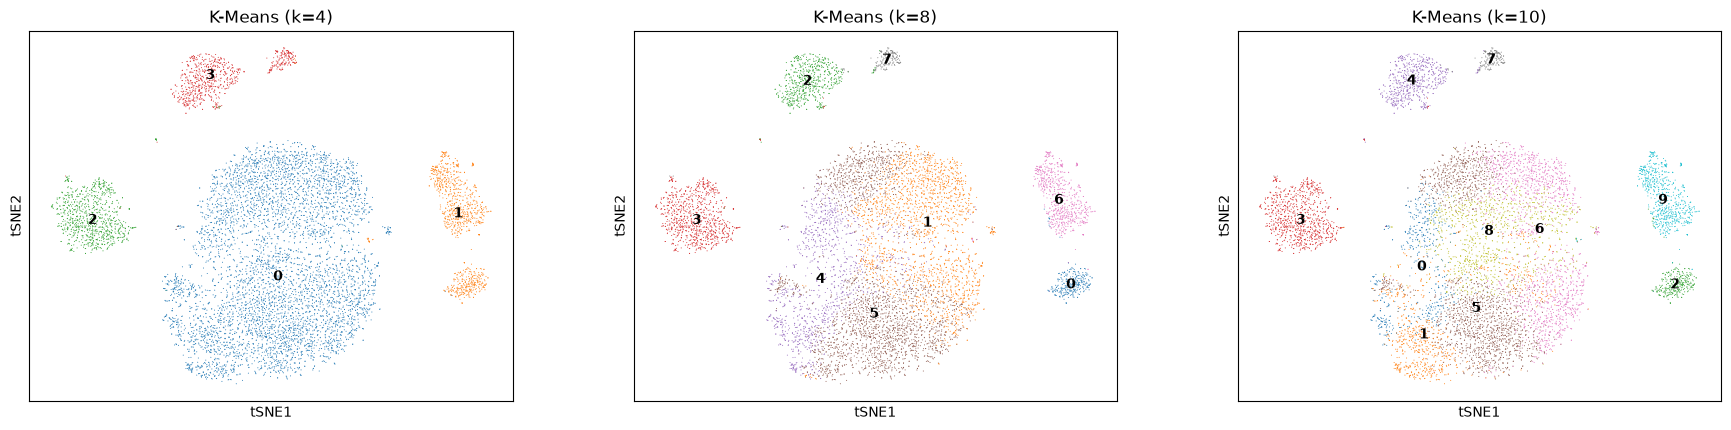

In [5]:
import scanpy as sc
from sklearn.cluster import KMeans

# Quality Control & Normalization
GSE65525_adata.var["mt"] = GSE65525_adata.var_names.str.lower().str.startswith("mt-")
GSE65525_adata.var["ribo"] = GSE65525_adata.var_names.str.startswith(("RPS", "RPL"))
GSE65525_adata.var["hb"] = GSE65525_adata.var_names.str.contains("^HB[^(P)]")

sc.pp.calculate_qc_metrics(GSE65525_adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)

# These are normal QC methods
# disproportionate mitochondrial genes can indicate that
# a cell was lysed too early and lost the majority of the rna within it
sc.pp.filter_cells(GSE65525_adata, min_genes=100)
sc.pp.filter_genes(GSE65525_adata, min_cells=3)

# remove cases where more than one cell was accidentally captured.
sc.pp.scrublet(GSE65525_adata, batch_key="cell_stage")

##
## There was some visualization that I did here, but I removed for the final script
## includding all of the QC visualization checks bloated the figueres by a lot
##


GSE65525_adata.layers["counts"] = GSE65525_adata.X.copy()
sc.pp.normalize_total(GSE65525_adata)
sc.pp.log1p(GSE65525_adata)


# Dimensionality Reduction (PCA + t-SNE)
# PCA for clustering
sc.tl.pca(GSE65525_adata, n_comps=50)

# t-SNE (calculated using the top 50 PCA dimensions) for visualization
sc.tl.tsne(GSE65525_adata, n_pcs=50)

# K-Means clusstering = Baseline on PCA Space (k = 4, 8, 10)
pca_coords = GSE65525_adata.obsm['X_pca'][:, :50]
k_values = [4, 8, 10]
kmeans_keys = []

for k in k_values:
    key = f"kmeans_k{k}"
    km = KMeans(n_clusters=k, random_state=5, n_init=10)
    # Convert predictions to categorical strings for Scanpy plotting
    GSE65525_adata.obs[key] = km.fit_predict(pca_coords).astype(str)
    kmeans_keys.append(key)


sc.pl.tsne(
    GSE65525_adata,
    color=kmeans_keys,
    ncols=3,
    size=2,
    legend_loc="on data",
    title=[f"K-Means (k={k})" for k in k_values]
)

INFO:root:multiplier_facility not set, using default value of 3...
INFO:root:number of facilities calculated as 30


Running SC3 consensus clustering for k=4, 8, 10...


INFO:root:original binary matrix shape: (8669, 20)
INFO:root:original binary matrix shape: (8669, 40)
INFO:root:original binary matrix shape: (8669, 50)


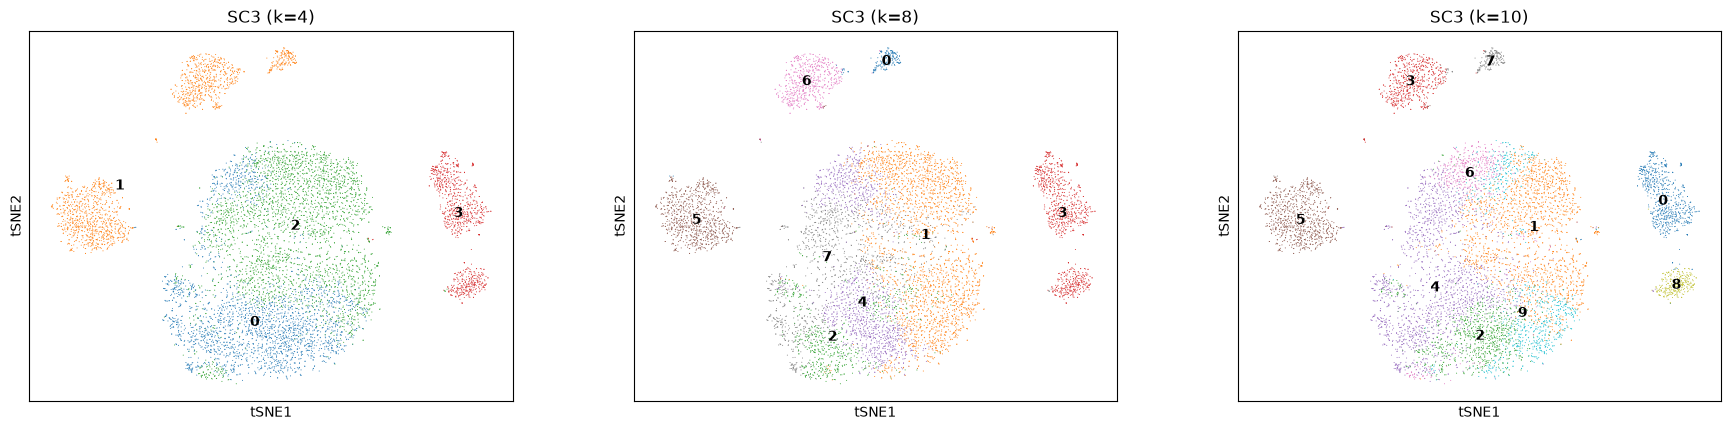

In [6]:
print("Running SC3 consensus clustering for k=4, 8, 10...")
# SC3 expects the data in .X to be log-normalized, which was done earlier with sc.pp.log1p
sc3s.tl.consensus(GSE65525_adata, n_clusters=[4, 8, 10])

# Visualize the three different cluster counts on the t-SNE coordinates
sc.pl.tsne(
    GSE65525_adata,
    color=["sc3s_4", "sc3s_8", "sc3s_10"],
    ncols=3,
    size=2,
    legend_loc="on data",
    title=["SC3 (k=4)", "SC3 (k=8)", "SC3 (k=10)"]
)


What's next: 
save what cluster each sample was assigned to
add some extra noise to the data - dropouts, etc
Re-run the analysis and see how different it is.


In [7]:
# Randomly cause some dropouts and add some additional noise to the data
GSE65525_noisy = copy.deepcopy(GSE65525_adata)

# Set a dropout rate and rng seed for reproducability.
dropout_rate = 0.15 
np.random.seed(5)

# For dense matrices, mask non-zero entries
matrix = GSE65525_noisy.X.copy()
non_zero_mask = matrix > 0
dropout_mask = np.random.binomial(1, 1 - dropout_rate, size=matrix.shape).astype(bool)
matrix[non_zero_mask & ~dropout_mask] = 0
GSE65525_noisy.X = matrix

print("Recalculating QC metrics for the noisy dataset...")
sc.pp.calculate_qc_metrics(
    GSE65525_noisy, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True
)

print("Done.")

Recalculating QC metrics for the noisy dataset...
Done.


In [8]:
# Re-run the previous analyzes
# How different is the clustering? 

1. Processing Noisy Dataset...
2. Running K-Means...


INFO:root:multiplier_facility not set, using default value of 3...
INFO:root:number of facilities calculated as 30


3. Running SC3s...


INFO:root:original binary matrix shape: (8669, 20)
INFO:root:original binary matrix shape: (8669, 40)
INFO:root:original binary matrix shape: (8669, 50)
... storing 'kmeans_k4' as categorical
... storing 'kmeans_k8' as categorical
... storing 'kmeans_k10' as categorical



4. Calculating Adjusted Rand Index (ARI) against True Cell Stage...
    K-Means (Noisy)  SC3 (Noisy)
k                               
4            0.3197       0.3978
8            0.2277       0.1253
10           0.1556       0.1001

5. Plotting visual comparison...


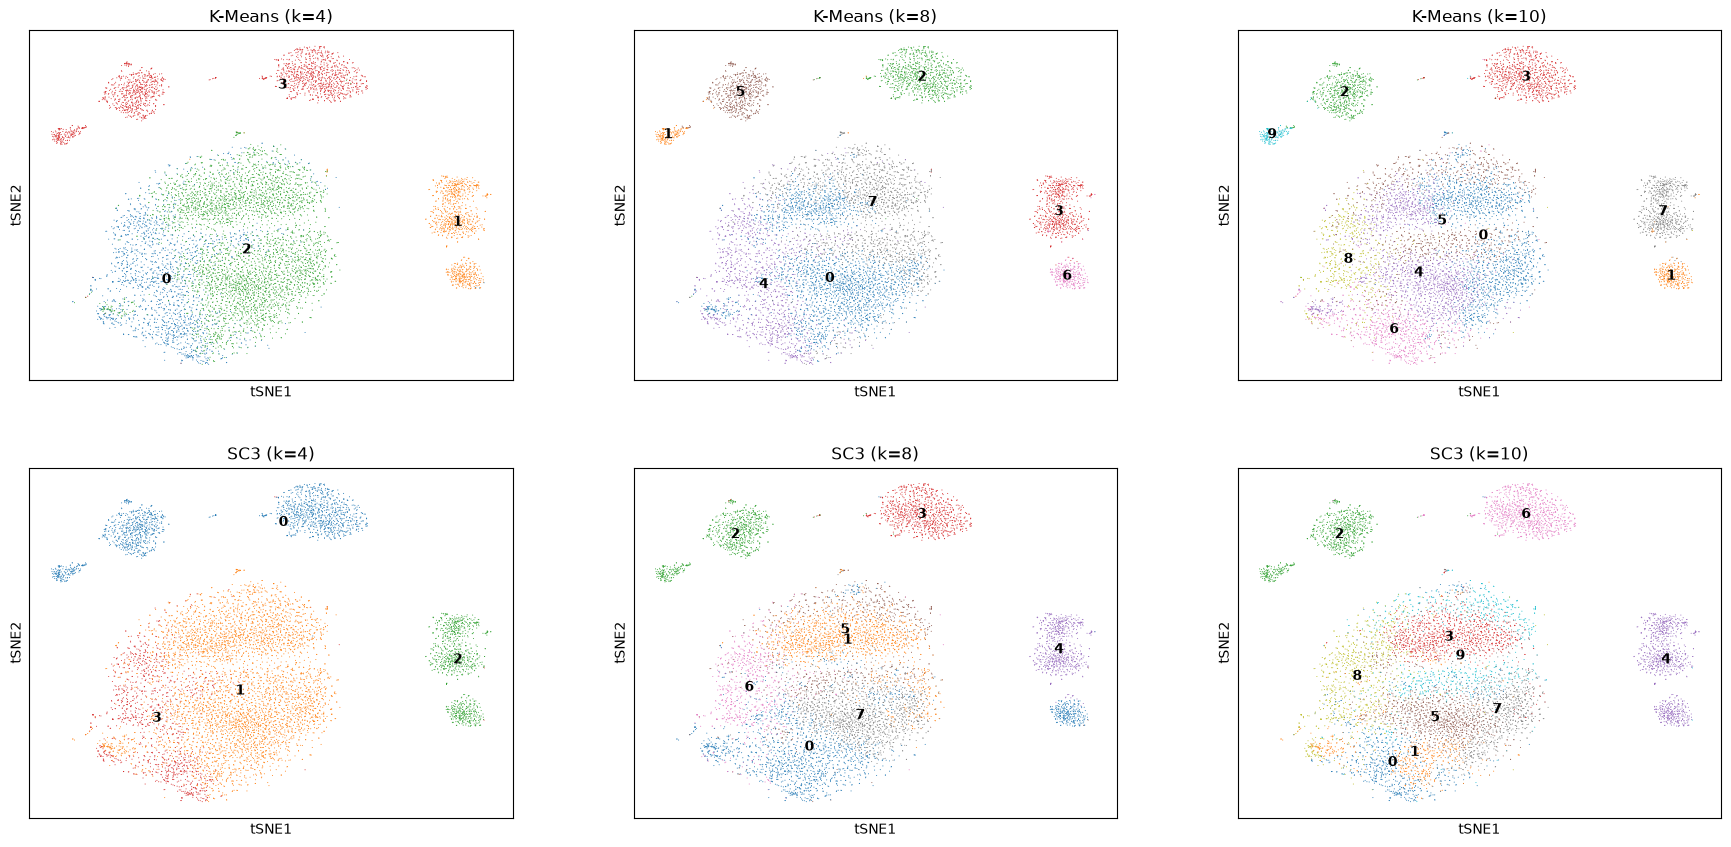

In [ ]:
# 1. Preprocess & Reduce the Noisy Dataset
print("1. R-Processing Noisy Dataset")
# Re-normalize and log-transform the dataset since the raw counts changed
GSE65525_noisy.layers["counts"] = GSE65525_noisy.X.copy()
sc.pp.normalize_total(GSE65525_noisy)
sc.pp.log1p(GSE65525_noisy)

# Calculate fresh PCA and t-SNE for the noisy data
sc.tl.pca(GSE65525_noisy, n_comps=50)
sc.tl.tsne(GSE65525_noisy, n_pcs=50)

# 2. Run K-Means Baseline
print("2. Running K-Means...")
pca_coords_noisy = GSE65525_noisy.obsm['X_pca'][:, :50]  
k_values = [4, 8, 10]

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    GSE65525_noisy.obs[f'kmeans_k{k}'] = km.fit_predict(pca_coords_noisy).astype(str)

# 3. Run SC3 Consensus Clustering

print("3. Running SC3s...")
sc3s.tl.consensus(GSE65525_noisy, n_clusters=k_values)

# Dynamically identify SC3 columns (e.g., 'sc3_4_clusters')
sc3_cols = [col for col in GSE65525_noisy.obs.columns if 'sc3' in col.lower()]



# 4. Comparison based on Adjusted Rand Index
print("\n4. Calculating Adjusted Rand Index (ARI) against True Cell Stage")
ari_results = []
true_labels = GSE65525_noisy.obs['cell_stage']

for k in k_values:
    # Match the exact SC3 column for this k
    sc3_col_for_k = next(col for col in sc3_cols if str(k) in col.replace('_', ' ').split())
    
    # Calculate scores
    kmeans_ari = adjusted_rand_score(true_labels, GSE65525_noisy.obs[f'kmeans_k{k}'])
    sc3_ari = adjusted_rand_score(true_labels, GSE65525_noisy.obs[sc3_col_for_k])
    
    ari_results.append({
        "k": k,
        "K-Means (Noisy)": round(kmeans_ari, 4),
        "SC3 (Noisy)": round(sc3_ari, 4)
    })

# Display as a clean Pandas DataFrame
ari_df = pd.DataFrame(ari_results).set_index("k")
print(ari_df)

# 5. Plotting
print("\n5. Plotting visual comparison...")

# Group all K-Means columns together, then all SC3 columns together
kmeans_cols = [f'kmeans_k{k}' for k in k_values]
sc3_specific_cols = [
    next(col for col in sc3_cols if str(k) in col.replace('_', ' ').split()) 
    for k in k_values
]

# This puts K-Means first (top row) and SC3 second (bottom row)
comparison_cols = kmeans_cols + sc3_specific_cols

# Create clean titles for the plots
plot_titles = [f"K-Means (k={k})" for k in k_values] + [f"SC3 (k={k})" for k in k_values]

# Plot all 6 results on the noisy t-SNE
sc.pl.tsne(
    GSE65525_noisy,
    color=comparison_cols,
    ncols=3,  # Forces 3 columns: Top row = K-Means, Bottom row = SC3
    size=2,
    legend_loc="on data",
    title=plot_titles
)